### SVM Model made using Python
Relevant Statistics:

Accuracy: 0.7474

Precision: 0.7273

Recall: 0.7822

F1 Score: 0.7537

ROC AUC: 0.7478

In [3]:
# Import required libraries (CUDA version)
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import machine learning libraries
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader
from sklearn.ensemble import RandomForestClassifier

from sklearn.svm import SVC


In [2]:
# Load the dataset into a pandas DataFrame
df = pd.read_csv('../Sino_CT.csv')

# Convert the 'embedding' column from string to a list
df['embedding'] = df['embedding'].apply(eval)

# Map the 'label' column to 0 for abnormal ('0,1') and 1 for normal ('1,0')
df['label'] = df['label'].apply(lambda x: 1 if x == '1,0' else 0)

# Define the target column
target_column = 'label'

# Load the embeddings and target values
X = np.array(df['embedding'].tolist(), dtype=np.float32)
y = df[target_column].values.astype(np.float32)

# Reshape y to be (n_samples, 1) for consistency with the model output
y = y.reshape(-1, 1)

# Split the data with 80 percent for training and 20 percent for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [7]:
model = SVC(kernel='rbf', probability=True, random_state=20)
model.fit(X_train_scaled, y_train.ravel())

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

c:\Users\bahra\anaconda3\envs\researchenv\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


KeyboardInterrupt: 

Accuracy: 0.7474
Precision: 0.7273
Recall: 0.7822
F1 Score: 0.7537
ROC AUC: 0.7478


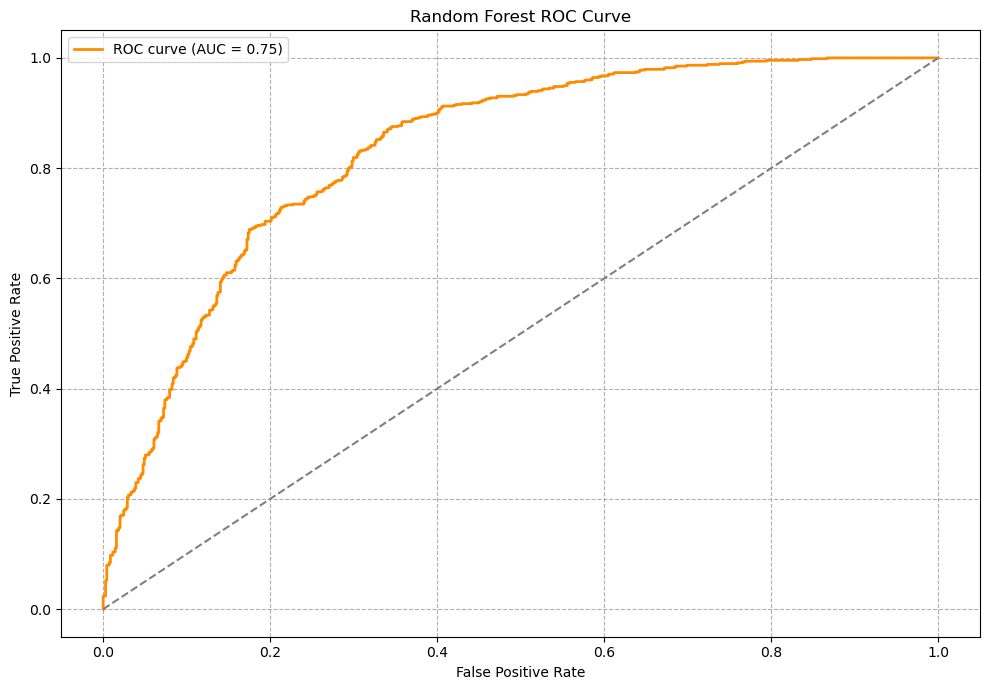

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, roc_auc_score
# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(10,7))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Random Forest ROC Curve')
plt.legend()
plt.grid(True, ls='--')
plt.tight_layout()
plt.show()